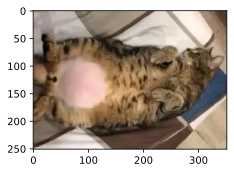

In [1]:
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

d2l.set_figsize()
img = d2l.Image.open('cat1.jpg')
d2l.plt.imshow(img)

In [2]:
# 对图片作用多次进行增广
def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    Y = [aug(img) for _ in range(num_rows * num_cols)]
    d2l.show_images(Y, num_rows, num_cols, scale=scale)

左右翻转

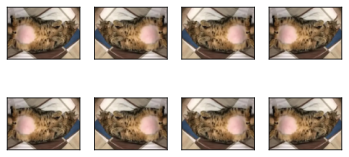

In [3]:
apply(img, torchvision.transforms.RandomHorizontalFlip())  #水平翻转，50%翻50%不翻

上下翻转

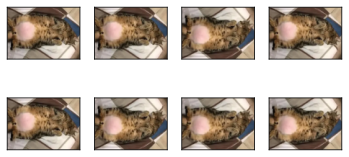

In [5]:
apply(img, torchvision.transforms.RandomVerticalFlip())

随机剪裁

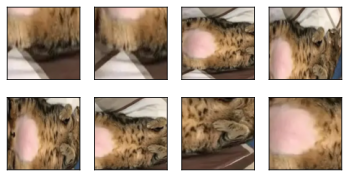

In [6]:
shape_aug = torchvision.transforms.RandomResizedCrop((200, 200), scale=(0.1, 1), ratio=(0.5, 2))
apply(img, shape_aug)

随机更改图像的亮度

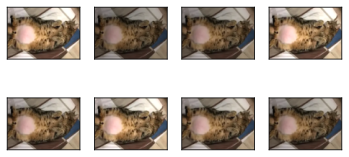

In [8]:
apply(img, torchvision.transforms.ColorJitter(brightness=0.5, contrast=0, saturation=0, hue=0))

随机更改图像的色调

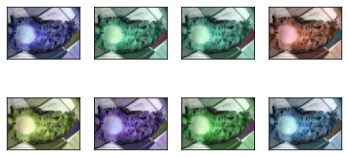

In [9]:
apply(img, torchvision.transforms.ColorJitter(brightness=0, contrast=0, saturation=0, hue=0.5))

随机更改图像的亮度（brightness）、对比度（contrast）、饱和度（saturation）和色调（hue）

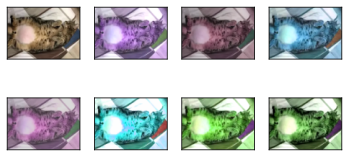

In [10]:
color_aug = torchvision.transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5)
apply(img, color_aug)

结合多种图像增广方法

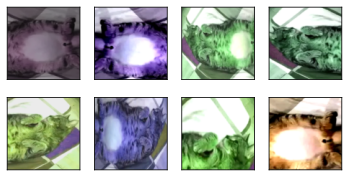

In [11]:
augs = torchvision.transforms.Compose([torchvision.transforms.RandomHorizontalFlip(), color_aug, shape_aug])
apply(img, augs)

使用图像增广进行训练

In [ ]:
all_images = torchvision.datasets.CIFAR10(train=True, root="../data", download=True)

In [13]:
train_augs = torchvision.transforms.Compose([torchvision.transforms.RandomHorizontalFlip(), torchvision.transforms.ToTensor()])  # ToTensor()将图片转为4d

test_augs = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])

训练与评估

In [ ]:
def train_batch_ch13(net, X, y, loss, trainer, devices):
    if isinstance(X, list):
        X = [x.to(devices[0]) for x in X]
    else:
        X = X.to(devices[0])
    y = y.to(devices[0])
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    train_loss_sum = l.sum()
    train_acc_sum = d2l.accuracy(pred, y)
    return train_loss_sum, train_acc_sum